### Imports

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage
from langchain.chains import RetrievalQA
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, START, END
from langchain.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.agents import initialize_agent, AgentType
from typing import TypedDict, Annotated, List

import requests


### Load LLm

In [3]:
# ------------------------- Agent LLM -------------------------
llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    temperature=0.7,
    max_tokens=256
)

### Custom tool and agent

In [4]:
# ------------------------- Custom tool -------------------------
@tool
def get_dummyjson_products(limit: int = 10) -> str:
    """
    Fetch products from DummyJSON API.
    Parameters:
        limit: number of products to return
    Returns:
        A string summary of products.
    """
    url = f"https://dummyjson.com/products?limit={limit}"
    response = requests.get(url)
    if response.ok:
        products = response.json().get("products", [])
        summaries = [f"{p['title']} (${p['price']})" for p in products]
        return "Products:\n" + "\n".join(summaries)
    else:
        return "Error fetching products."

# Manually assign name and description to make it compatible with ReAct agents
get_dummyjson_products.description = "Fetch products from DummyJSON API. Input: number of products."
get_dummyjson_products.name = "get_dummyjson_products"

tool_agent = initialize_agent(
    llm=llm, 
    tools=[get_dummyjson_products], 
    agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True,
    handle_parsing_errors=True
)

tool_agent.invoke("Get 5 dummy products")

/var/folders/tb/f1vll7rj721bdvsrgr1bs2lh0000gs/T/ipykernel_76394/2190112295.py:24: LangChainDeprecationWarning: LangChain agents will continue to be supported, but it is recommended for new use cases to be built with LangGraph. LangGraph offers a more flexible and full-featured framework for building agents, including support for tool-calling, persistence of state, and human-in-the-loop workflows. For details, refer to the `LangGraph documentation <https://langchain-ai.github.io/langgraph/>`_ as well as guides for `Migrating from AgentExecutor <https://python.langchain.com/docs/how_to/migrate_agent/>`_ and LangGraph's `Pre-built ReAct agent <https://langchain-ai.github.io/langgraph/how-tos/create-react-agent/>`_.
  tool_agent = initialize_agent(




> Entering new AgentExecutor chain...
I need to fetch 5 dummy products using the get_dummyjson_products tool.
Action: get_dummyjson_products
Action Input: 5
Observation: Products:
Essence Mascara Lash Princess ($9.99)
Eyeshadow Palette with Mirror ($19.99)
Powder Canister ($14.99)
Red Lipstick ($12.99)
Red Nail Polish ($8.99)
Thought:I now have the 5 requested dummy products.
Final Answer: Essence Mascara Lash Princess ($9.99), Eyeshadow Palette with Mirror ($19.99), Powder Canister ($14.99), Red Lipstick ($12.99), Red Nail Polish ($8.99)

> Finished chain.


{'input': 'Get 5 dummy products',
 'output': 'Essence Mascara Lash Princess ($9.99), Eyeshadow Palette with Mirror ($19.99), Powder Canister ($14.99), Red Lipstick ($12.99), Red Nail Polish ($8.99)'}

### Create RAG and rag_chain
-  Sentence-transformers model used for embeddings

- FAISS vectorstore from the embedded PDF content

In [5]:
PDF_URL = "https://www.upl-ltd.com/images/people/downloads/Leave-Policy-India.pdf"
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

def load_and_split_pdf():
    documents = PyPDFLoader(PDF_URL).load()
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
    return text_splitter.split_documents(documents)

def create_vectorstore():
    docs = load_and_split_pdf()
    embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL_NAME)
    vectorstore = FAISS.from_documents(docs, embeddings)
    return vectorstore

vectorstore = create_vectorstore()
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

rag_chain = RetrievalQA.from_chain_type(
    llm=llm,
    retriever=retriever,
    return_source_documents=True,
)


/Users/anupeshkumar.verma/Downloads/Projects/AI_ML/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Define LangGraph State
Structure of the state that flows through the LangGraph

In [6]:
class AgentState(TypedDict):
    messages: Annotated[List[HumanMessage | AIMessage], "The messages in the conversation"]

### Routing Logic
Basic router function that determines which agent to use

In [7]:
def router(state: AgentState):
    """Simple rule-based routing"""
    user_input = state["messages"][-1]["content"].lower()
    if "product" in user_input:
        return "tool_agent"
    else:
        return "rag_agent"

### Define Agent Node Functions
1. LangGraph node that wraps the tool agent

2. LangGraph node that wraps the RAG chain

In [8]:

def tool_agent_node(state: AgentState) -> AgentState:
    response = tool_agent.invoke(state["messages"])
    print(response)
    return {"messages": state["messages"] + [AIMessage(content=response["output"])]}

def rag_agent_node(state: AgentState) -> AgentState:
    last_message = state["messages"][-1]["content"]
    response = rag_chain.invoke({"query": last_message})
    return {"messages": state["messages"] + [AIMessage(content=response["result"])]}

### LangGraph Setup

In [9]:
builder = StateGraph(AgentState)

# graph.add_node("router_node", router)
builder.add_node("tool_agent_node", tool_agent_node)
builder.add_node("rag_agent_node", rag_agent_node)

builder.add_conditional_edges(
    START,  
    router,
    {
        "tool_agent": "tool_agent_node",
        "rag_agent": "rag_agent_node"
    }
)
builder.add_edge(["tool_agent_node","rag_agent_node"], END)

graph = builder.compile()

### Visualize the graph

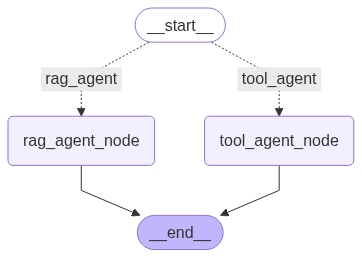

In [10]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

### Test run

In [11]:
messages = [
    {"role": "ai", "content": "You are a helpful assistant."},
    {"role": "user", "content": "List 5 dummy products."},
    # {"role": "user", "content": "How many sick leaves are mentioned in the policy?"},
]

response = graph.invoke({"messages":messages})

for msg in response["messages"]:
    if isinstance(msg, HumanMessage):
        print(f"👤 Human: {msg.content}")
    elif isinstance(msg, AIMessage):
        # If function call exists, print it separately
        if "function_call" in msg.additional_kwargs:
            func_call = msg.additional_kwargs["function_call"]
            print(f"\n🤖 AI (function call): {func_call['name']} with args {func_call['arguments']}")
        elif msg.content:
            print(f"\n🤖 AI: {msg.content}")
    elif isinstance(msg, ToolMessage):
        print(f"\n🔧 Tool ({msg.name}): {msg.content}")



> Entering new AgentExecutor chain...
I need to fetch 5 products from the DummyJSON API.
Action: get_dummyjson_products
Action Input: 5
Observation: Products:
Essence Mascara Lash Princess ($9.99)
Eyeshadow Palette with Mirror ($19.99)
Powder Canister ($14.99)
Red Lipstick ($12.99)
Red Nail Polish ($8.99)
Thought:I now have the list of 5 dummy products.
Final Answer: Essence Mascara Lash Princess ($9.99), Eyeshadow Palette with Mirror ($19.99), Powder Canister ($14.99), Red Lipstick ($12.99), Red Nail Polish ($8.99)

> Finished chain.
{'input': [{'role': 'ai', 'content': 'You are a helpful assistant.'}, {'role': 'user', 'content': 'List 5 dummy products.'}], 'output': 'Essence Mascara Lash Princess ($9.99), Eyeshadow Palette with Mirror ($19.99), Powder Canister ($14.99), Red Lipstick ($12.99), Red Nail Polish ($8.99)'}

🤖 AI: Essence Mascara Lash Princess ($9.99), Eyeshadow Palette with Mirror ($19.99), Powder Canister ($14.99), Red Lipstick ($12.99), Red Nail Polish ($8.99)


### REPL-based Runtime
- REPL -> Read-Eval-Print Loop

In [ ]:
state = AgentState({"messages": [{"role": "user", "content": "You are a hellpful assistant"}]})

print("Welcome to the multi-agent system.\n")
while True:
    user_input = input("Ask a question (or 'exit'): ")
    if user_input.lower() in {"quit","exit"}:
        print("Good Bye!")
        break
    state["messages"].append({"role": "user", "content": user_input})
    state = graph.invoke(state)
    print("\n👤 You:", user_input)
    print("🤖 Bot:", state["messages"][-1].content)


Welcome to the multi-agent system.


👤 You: How many sick leaves are mentioned in the policy?
🤖 Bot: As per the policy, nine days of sick leave are available to employees per annum. From January 1, 2021, sick leave will not be accumulated or encashed for existing and new employees.


> Entering new AgentExecutor chain...
I need to list 5 dummy products. I can use the `get_dummyjson_products` tool to get the product information.
Action: get_dummyjson_products
Action Input: 5
Observation: Products:
Essence Mascara Lash Princess ($9.99)
Eyeshadow Palette with Mirror ($19.99)
Powder Canister ($14.99)
Red Lipstick ($12.99)
Red Nail Polish ($8.99)
Thought:I have successfully retrieved 5 dummy products.
Final Answer: Essence Mascara Lash Princess ($9.99), Eyeshadow Palette with Mirror ($19.99), Powder Canister ($14.99), Red Lipstick ($12.99), Red Nail Polish ($8.99)

> Finished chain.
{'input': [{'role': 'user', 'content': 'You are a hellpful assistant'}, {'role': 'user', 'content': 'How many